In [435]:
import os
import random
import string
import shutil
from PIL import Image, ImageDraw, ImageFont

OUTPUT_DIR = "generated_captchas"

def reset_output_dir(path):
    if os.path.exists(path):
        shutil.rmtree(path)
    os.makedirs(path)

reset_output_dir(OUTPUT_DIR)

In [436]:
def generate_captcha_text(length=4):
    characters = string.ascii_lowercase + string.digits
    return ''.join(random.choice(characters) for _ in range(length))

def create_and_save_captcha(text, output_dir=OUTPUT_DIR):
    width, height = 160, 60
    background_color = (255, 255, 255)
    text_color = (0, 0, 0)

    image = Image.new('RGB', (width, height), color=background_color)
    draw = ImageDraw.Draw(image)

    try:
        font = ImageFont.truetype("font.ttf", 40)
    except IOError:
        font = ImageFont.load_default()

    bbox = draw.textbbox((0, 0), text, font=font)
    text_width = bbox[2] - bbox[0]
    text_height = bbox[3] - bbox[1]

    x = (width - text_width) / 2
    y = (height - text_height) / 2

    draw.text((x, y), text, fill=text_color, font=font)

    file_path = os.path.join(output_dir, f"{text}.png")
    image.save(file_path)

    return file_path

In [437]:
for _ in range(20):
    captcha_text = generate_captcha_text(4)
    create_and_save_captcha(captcha_text)

print(f"20 captchas saved to '{OUTPUT_DIR}'.")

20 captchas saved to 'generated_captchas'.


In [438]:
import cv2
import numpy as np
import glob

NOISY_DIR = "noisy_captchas"
FILTERED_DIR = "filtered_captchas"

def reset_dir(path):
    if os.path.exists(path):
        shutil.rmtree(path)
    os.makedirs(path)

reset_dir(NOISY_DIR)
reset_dir(FILTERED_DIR)

In [439]:
def add_sp_noise(image_path, output_path, prob=0.03):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    noisy = np.copy(img)
    rnd = np.random.rand(*img.shape)
    
    noisy[rnd < prob / 2] = 0
    noisy[rnd > 1 - prob / 2] = 255
    
    cv2.imwrite(output_path, noisy)

image_paths = glob.glob(os.path.join(OUTPUT_DIR, "*.png"))
for path in image_paths:
    filename = os.path.basename(path)
    out_path = os.path.join(NOISY_DIR, filename)
    add_sp_noise(path, out_path)

print(f"Noisy images saved to '{NOISY_DIR}'.")

Noisy images saved to 'noisy_captchas'.


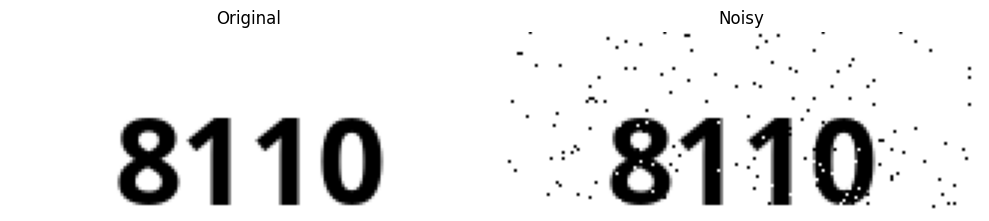

In [440]:
import os
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

original_images = [f for f in os.listdir(OUTPUT_DIR) if f.endswith('.png')]
sample_image_name = random.choice(original_images)

orig_path = os.path.join(OUTPUT_DIR, sample_image_name)
noisy_path = os.path.join(NOISY_DIR, sample_image_name)

img_orig = mpimg.imread(orig_path)
img_noisy = mpimg.imread(noisy_path)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].imshow(img_orig)
axes[0].set_title("Original")
axes[0].axis('off')

axes[1].imshow(img_noisy, cmap='gray')
axes[1].set_title("Noisy")
axes[1].axis('off')

plt.tight_layout()
plt.show()

In [441]:
def apply_filter_gaussian(image_path, output_path, kernel_size=3):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    filtered = cv2.GaussianBlur(img, (kernel_size, kernel_size), 0)
    cv2.imwrite(output_path, filtered)

noisy_paths = glob.glob(os.path.join(NOISY_DIR, "*.png"))
for path in noisy_paths:
    filename = os.path.basename(path)
    out_path = os.path.join(FILTERED_DIR, filename)
    apply_filter_gaussian(path, out_path)

print(f"Filtered images using Gaussian Blur saved to '{FILTERED_DIR}'.")

Filtered images using Gaussian Blur saved to 'filtered_captchas'.


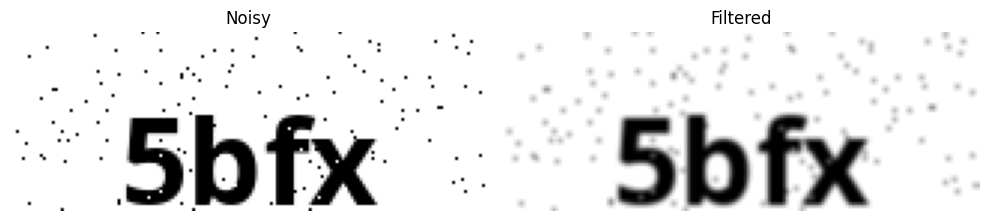

In [442]:
import os
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

noisy_images = [f for f in os.listdir(NOISY_DIR) if f.endswith('.png')]
sample_image_name = random.choice(noisy_images)

noisy_path = os.path.join(NOISY_DIR, sample_image_name)
filtered_path = os.path.join(FILTERED_DIR, sample_image_name)

img_noisy = mpimg.imread(noisy_path)
img_filtered = mpimg.imread(filtered_path)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].imshow(img_noisy, cmap='gray')
axes[0].set_title("Noisy")
axes[0].axis('off')

axes[1].imshow(img_filtered, cmap='gray')
axes[1].set_title("Filtered")
axes[1].axis('off')

plt.tight_layout()
plt.show()

# Part 1

## CAPTCHA Generation
First, 20 random CAPTCHA texts were generated. Each CAPTCHA consists of 4 characters, and the characters were chosen randomly from two groups: English lowercase letters (`a-z`) and digits (`0-9`).  
Then, for each generated text, an image with a white background and black text was created and saved.

## Labeling
Each generated image was labeled automatically using its own text. In practice, the filename of each image is the CAPTCHA text itself. For example, if the generated CAPTCHA text is `a4d9`, the image is saved as `a4d9.png`. Therefore, the label of every image is directly available from its filename, and no separate annotation file is needed.

## Adding Salt-and-Pepper Noise
After generating the original CAPTCHA images, salt-and-pepper noise was added to them. This type of noise randomly changes some pixels to black or white. As a result, the noisy images contain scattered bright and dark points that make the CAPTCHA slightly harder to read.  
The noisy images were saved separately so they could be compared with the original images.

## Filtering the Noisy Images
To reduce the effect of the noise, a Gaussian filter was applied to the noisy images. This filter smooths the image by averaging pixel values with their neighbors based on a Gaussian distribution. After filtering, the images become slightly smoother and some of the noise is reduced.

## Comparison with Original Images
By comparing the original, noisy, and filtered images, it can be observed that:

- The original images are clean and sharp.
- The noisy images contain random black and white dots caused by salt-and-pepper noise.
- The filtered images are smoother than the noisy ones, and part of the noise is reduced.
- At the same time, the Gaussian filter slightly blurs the edges of the characters.

## Answer to the Questions

### 1. Explaining the kernel and the reason for using it
A Gaussian filter with a `3×3` kernel was used.  
The reason for choosing this kernel is that it provides a good balance between smoothing and preserving the characters:

- It reduces small noisy pixels.
- It does not blur the CAPTCHA text too heavily.
- It is computationally simple and efficient.
- A larger kernel would create stronger smoothing, but it could also make the letters and digits less clear.

So, the `3×3` kernel was selected because it is a reasonable choice for light noise reduction while keeping the CAPTCHA readable.
We know that Median Filter works best for pepper salt noise and also I applied it in part 2. This filtering just reduce the effect of the noises...

Denoised images saved to 'denoised_captchas'.


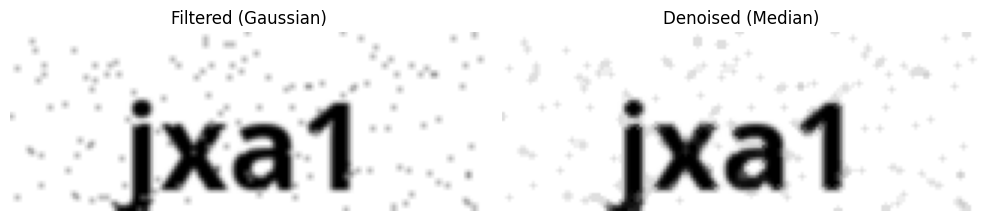

In [443]:
DENOISED_DIR = "denoised_captchas"
reset_dir(DENOISED_DIR)

filtered_images_paths = glob.glob(os.path.join(FILTERED_DIR, "*.png"))

for path in filtered_images_paths:
    filename = os.path.basename(path)
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    
    denoised_img = cv2.medianBlur(img, 3)
    
    out_path = os.path.join(DENOISED_DIR, filename)
    cv2.imwrite(out_path, denoised_img)

print(f"Denoised images saved to '{DENOISED_DIR}'.")

sample_name = random.choice(os.listdir(FILTERED_DIR))
img_filtered_sample = mpimg.imread(os.path.join(FILTERED_DIR, sample_name))
img_denoised_sample = mpimg.imread(os.path.join(DENOISED_DIR, sample_name))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(img_filtered_sample, cmap='gray')
axes[0].set_title("Filtered (Gaussian)")
axes[0].axis('off')

axes[1].imshow(img_denoised_sample, cmap='gray')
axes[1].set_title("Denoised (Median)")
axes[1].axis('off')

plt.tight_layout()
plt.show()

Sharpened images saved to 'sharpened_captchas'.


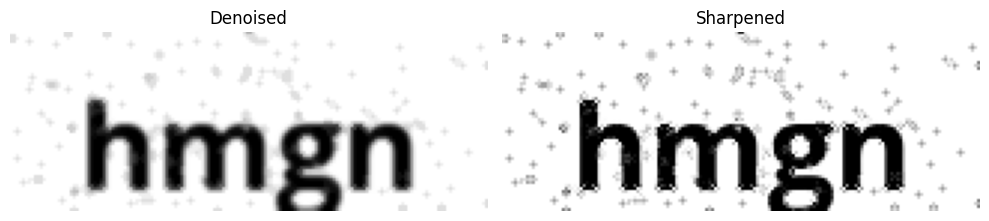

In [444]:
SHARPENED_DIR = "sharpened_captchas"
reset_dir(SHARPENED_DIR)

sharpen_kernel = np.array([[0, -1, 0], 
                           [-1, 5, -1], 
                           [0, -1, 0]])

denoised_images_paths = glob.glob(os.path.join(DENOISED_DIR, "*.png"))

for path in denoised_images_paths:
    filename = os.path.basename(path)
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    
    sharpened_img = cv2.filter2D(img, -1, sharpen_kernel)
    
    out_path = os.path.join(SHARPENED_DIR, filename)
    cv2.imwrite(out_path, sharpened_img)

print(f"Sharpened images saved to '{SHARPENED_DIR}'.")

sample_name = random.choice(os.listdir(DENOISED_DIR))
img_denoised_sample = mpimg.imread(os.path.join(DENOISED_DIR, sample_name))
img_sharp_sample = mpimg.imread(os.path.join(SHARPENED_DIR, sample_name))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(img_denoised_sample, cmap='gray')
axes[0].set_title("Denoised")
axes[0].axis('off')

axes[1].imshow(img_sharp_sample, cmap='gray')
axes[1].set_title("Sharpened")
axes[1].axis('off')

plt.tight_layout()
plt.show()

Binarized (inverted) images saved to 'binarized_captchas'.


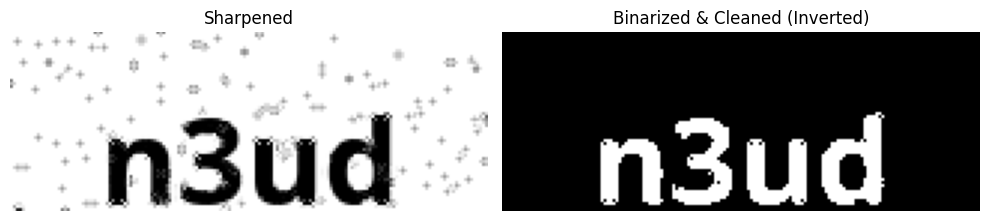

In [445]:
BINARIZED_DIR = "binarized_captchas"
reset_dir(BINARIZED_DIR)

sharpened_images_paths = glob.glob(os.path.join(SHARPENED_DIR, "*.png"))
min_size_threshold = 40

for path in sharpened_images_paths:
    filename = os.path.basename(path)
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    
    _, binary = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(binary, connectivity=8)
    
    cleaned = np.zeros_like(binary)
    
    for i in range(1, num_labels):
        area = stats[i, cv2.CC_STAT_AREA]
        if area >= min_size_threshold:
            cleaned[labels == i] = 255
            
    out_path = os.path.join(BINARIZED_DIR, filename)
    cv2.imwrite(out_path, cleaned)

print(f"Binarized (inverted) images saved to '{BINARIZED_DIR}'.")

sample_name = random.choice(os.listdir(SHARPENED_DIR))
img_sharp_sample = mpimg.imread(os.path.join(SHARPENED_DIR, sample_name))
img_bin_sample = mpimg.imread(os.path.join(BINARIZED_DIR, sample_name))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(img_sharp_sample, cmap='gray')
axes[0].set_title("Sharpened")
axes[0].axis('off')

axes[1].imshow(img_bin_sample, cmap='gray')
axes[1].set_title("Binarized & Cleaned (Inverted)")
axes[1].axis('off')

plt.tight_layout()
plt.show()

# Part 2

## General Overview
In this part, the images that had already been filtered with Gaussian blur were processed further. First, a median filter was applied to reduce remaining noise. Then, a sharpening operation was used to enhance the edges of the characters. Finally, the sharpened images were converted into binary form and small unwanted connected components were removed. At the end, the results of each stage were visually compared with the previous stage.

## 1. Denoising with Median Filter
The first step in this section was denoising. For this purpose, a median filter with a `3×3` kernel was applied to the filtered CAPTCHA images.

The median filter works by replacing each pixel with the median value of its neighboring pixels. This method is especially effective for removing salt-and-pepper noise because such noise appears as isolated bright or dark pixels, and the median operation can eliminate them without strongly blurring the edges of the characters.

### Why was the median filter used?
The median filter was used because:

- it is very effective for removing salt-and-pepper noise,
- it preserves edges better than Gaussian smoothing,
- it reduces isolated noisy pixels while keeping the structure of letters and digits clearer.

After this step, the images became cleaner than the Gaussian-filtered versions.

## 2. Sharpening the Images
After denoising, a sharpening filter was applied to the images. The goal of sharpening is to make the edges of the characters more distinct.

This operation increases contrast around edges, so the letters and digits become clearer and better separated from the background. Since the previous denoising and filtering steps can slightly blur the characters, sharpening helps restore some of the lost detail.

### Purpose of sharpening
The sharpening step was important because:

- the previous smoothing operations reduced image sharpness,
- CAPTCHA characters need clear boundaries for recognition,
- stronger edges improve visual quality and can help later processing steps.

As a result, the sharpened images appear more defined than the denoised images.

## 3. Binarization and Cleaning
In the final step, the sharpened grayscale images were converted into binary images. Binarization means that each pixel is converted into one of two values only: foreground or background.

For this purpose, Otsu’s thresholding method was used. This method automatically chooses a threshold value based on the intensity distribution of the image. The output was stored in inverted binary form, meaning that the characters appear white and the background appears black.

After binarization, connected component analysis was performed. Very small connected regions were removed based on an area threshold. This cleaning step helps eliminate tiny remaining noise spots that do not belong to the CAPTCHA characters.

### Why was connected component cleaning used?
This cleaning stage was used because after thresholding, some small noisy regions may still remain in the image. These tiny components are not part of the actual characters, so removing them improves the final binary output.

## Comparison of Stages
By comparing the outputs of the three stages, the following can be observed:

- **Filtered (Gaussian)** images are smoother, but may still contain residual noise and some blur.
- **Denoised (Median)** images contain less impulse noise and preserve the character shapes better.
- **Sharpened** images have clearer edges and improved character visibility.
- **Binarized and cleaned** images contain only the main foreground regions, making the CAPTCHA characters more distinct from the background.

## Answers to the Questions

### 1. Why is the median filter used?
The median filter is used because it is particularly suitable for removing salt-and-pepper noise. Unlike Gaussian smoothing, it removes isolated noisy pixels while preserving important edges. This makes it a better choice for CAPTCHA images where the shapes of letters and digits must remain clear.

### 2. Why is sharpening applied after denoising?
Sharpening is applied after denoising because noise reduction can make the image slightly blurry. The sharpening step restores edge clarity and makes the characters more distinct. This improves readability and can help later tasks such as segmentation and recognition.

### 3. Why is binarization applied?
Binarization is applied to separate the foreground (characters) from the background. This simplifies the image and makes the CAPTCHA text easier to analyze. Binary images are often preferred in recognition tasks because they reduce unnecessary intensity variations.

### 4. Why are small connected components removed?
Small connected components are usually caused by residual noise or unwanted artifacts. They are removed because they do not belong to the real CAPTCHA characters. This cleaning step improves the final binary image by keeping only the meaningful foreground regions.

### 5. Sharpening and De-blurring

#### Definition of Sharpening
Sharpening is an image enhancement technique used to make edges and details more visible. It increases the contrast between neighboring pixels, especially around boundaries. In CAPTCHA images, sharpening makes the borders of letters and digits clearer.

In this project, a sharpening kernel was used after denoising. The purpose was to recover some of the edge clarity that may have been reduced by Gaussian and median filtering.

#### Definition of De-blurring
De-blurring is a more advanced image restoration technique used to remove blur from an image. It tries to reconstruct the original sharp image by estimating or modeling the blur process. Common de-blurring methods include inverse filtering, Wiener filtering, and Richardson-Lucy deconvolution.

De-blurring is usually useful when the image is blurred due to motion blur, defocus blur, or camera-related blur.

#### Reason for Choosing Sharpening
In this work, sharpening was chosen instead of full de-blurring because the images were not heavily blurred. The blur was mainly caused by previous smoothing filters such as Gaussian blur and median filtering. Therefore, a simple sharpening filter was enough to improve the visibility of the CAPTCHA characters.

Sharpening was selected because:

- it is simple and fast,
- it improves character edges,
- it does not require estimating a blur model,
- it is suitable for lightly blurred CAPTCHA images,
- it helps make the letters and digits more readable.

On the other hand, de-blurring methods usually require more information about the type of blur. For example, some de-blurring methods need the point spread function or blur kernel. If this blur model is not known, de-blurring may produce poor results or even amplify noise. Since the CAPTCHA images in this task only had mild blur, sharpening was a better and more practical choice.

#### What is the Threshold?
There are two types of thresholds in this part:

1. **Intensity threshold for binarization**
2. **Area threshold for removing small connected components**

#### Is the threshold a fixed value?

The intensity threshold used for binarization is not fixed in this code. Otsu’s method is used, which automatically calculates the best threshold for each image based on its pixel intensity distribution. This is useful because different images may have slightly different brightness or contrast.

However, the area threshold for removing small connected components is fixed in the code. In this implementation, the value is:

`min_size_threshold = 40`

This means that any connected component with an area smaller than 40 pixels is considered noise and removed.

#### Is a fixed area threshold always suitable?
No, a fixed area threshold is not always suitable for all images. The best threshold depends on several factors, such as:

- image size,
- font size,
- thickness of characters,
- amount of noise,
- resolution of the CAPTCHA images.

In this project, the value `40` was chosen because the CAPTCHA images have the same size and similar font style. Therefore, small noise components usually have an area less than this value, while real letters and digits are much larger.

For more general cases, the area threshold can be selected experimentally or calculated adaptively based on the image size or the average size of detected components.

#### Reason for Using This Method
This method was used because after binarization, many small noise pixels become separate connected components. By analyzing the area of each component, it is possible to remove small noisy regions while keeping the main CAPTCHA characters.

This improves the final image and makes it cleaner for later tasks such as segmentation or character recognition.

'09x4.png': Extracted 4 characters.
'2omd.png': Extracted 4 characters.
'5bfx.png': Extracted 3 characters.
'7p4s.png': Extracted 4 characters.
'8110.png': Extracted 4 characters.
'8a2f.png': Extracted 4 characters.
'b8sq.png': Extracted 4 characters.
'bjet.png': Extracted 4 characters.
'cm28.png': Extracted 4 characters.
'g3a4.png': Extracted 4 characters.
'gzyi.png': Extracted 4 characters.
'hks0.png': Extracted 4 characters.
'hmgn.png': Extracted 4 characters.
'iy0w.png': Extracted 4 characters.
'jxa1.png': Extracted 4 characters.
'kgps.png': Extracted 4 characters.
'n3ud.png': Extracted 4 characters.
's9u7.png': Extracted 4 characters.
't04s.png': Extracted 4 characters.
'wl5g.png': Extracted 4 characters.


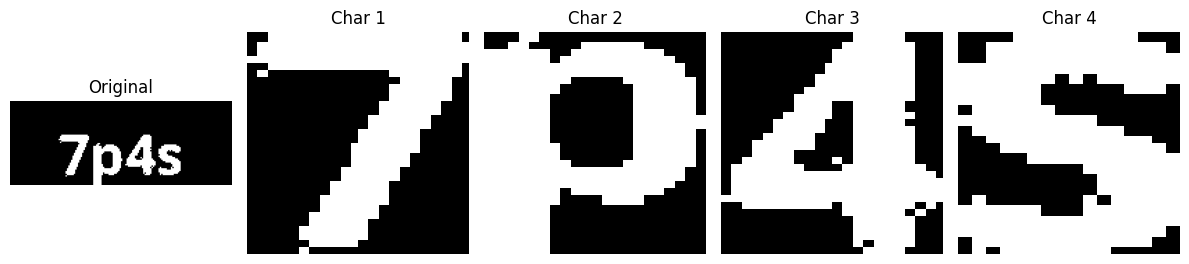

In [446]:
SEGMENTED_DIR = "segmented_captchas"
reset_dir(SEGMENTED_DIR)

binarized_images_paths = glob.glob(os.path.join(BINARIZED_DIR, "*.png"))

for path in binarized_images_paths:
    filename = os.path.basename(path)
    base_name = os.path.splitext(filename)[0]
    
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(img, connectivity=8)
    
    char_components = []
    for i in range(1, num_labels):
        x, y, w, h, area = stats[i]
        char_components.append((x, y, w, h))
        
    char_components.sort(key=lambda item: item[0])
    
    print(f"'{filename}': Extracted {len(char_components)} characters.")
    
    for idx, (x, y, w, h) in enumerate(char_components):
        char_img = img[y:y+h, x:x+w]
        
        resized_char = cv2.resize(char_img, (64, 64), interpolation=cv2.INTER_NEAREST)
        
        out_name = f"{base_name}_{idx}.png"
        out_path = os.path.join(SEGMENTED_DIR, out_name)
        cv2.imwrite(out_path, resized_char)

sample_path = random.choice(binarized_images_paths)
sample_base = os.path.splitext(os.path.basename(sample_path))[0]
sample_img = mpimg.imread(sample_path)

segmented_samples = sorted(glob.glob(os.path.join(SEGMENTED_DIR, f"{sample_base}_*.png")))

fig, axes = plt.subplots(1, len(segmented_samples) + 1, figsize=(12, 3))
axes[0].imshow(sample_img, cmap='gray')
axes[0].set_title(f"Original")
axes[0].axis('off')

for i, seg_path in enumerate(segmented_samples):
    img_seg = mpimg.imread(seg_path)
    axes[i+1].imshow(img_seg, cmap='gray')
    axes[i+1].set_title(f"Char {i+1}")
    axes[i+1].axis('off')

plt.tight_layout()
plt.show()

# Part 3

## General Overview

In this part, the binarized CAPTCHA images from the previous stage are used as input. Since these images have already been cleaned and converted into binary format, the foreground regions mainly represent the CAPTCHA characters.

The code detects connected components in each binary image, extracts each component as a separate character, sorts the characters from left to right, resizes them to `64×64`, and saves them in a new directory.

The output of this section is stored in:

`segmented_captchas`

Each saved image corresponds to one extracted character from a CAPTCHA image.

---

## 1. Preparing the Output Directory

At the beginning of this section, a new directory is created for saving the segmented characters. If the directory already exists, it is reset so that old results do not mix with the new outputs.

This helps keep the output folder organized and ensures that only the latest segmented character images are stored.

---

## 2. Reading the Binarized CAPTCHA Images

The code reads all binary CAPTCHA images from the previous output folder:

`binarized_captchas`

These images have already passed through several preprocessing steps:

- noise reduction,
- sharpening,
- binarization,
- removal of small connected components.

Because of these steps, the remaining foreground regions in the binary images mostly correspond to actual CAPTCHA characters.

---

## 3. Connected Component Analysis

For each binarized image, connected component analysis is applied.

Connected component analysis detects groups of connected foreground pixels. In this project, each connected foreground region is expected to represent one CAPTCHA character.

The background component is ignored, and only foreground components are used for character extraction.

---

## 4. Extracting Characters from Each Image

After detecting the connected components, the bounding box of each component is used to crop the character from the binary image.

Each bounding box is described by:

- `x`: horizontal position,
- `y`: vertical position,
- `w`: width,
- `h`: height.

Using these values, the code extracts the region containing the character.

As a result, each full CAPTCHA image is split into separate character images.

---

## 5. Sorting Characters from Left to Right

The extracted connected components are sorted based on their horizontal position.

This is done using the `x` coordinate of each bounding box.

Sorting is important because CAPTCHA characters should be stored in the same order as they appear in the original image. Since the text is read from left to right, sorting by the `x` coordinate preserves the correct character sequence.

---

## 6. Reporting the Number of Extracted Characters

For each CAPTCHA image, the code prints the number of extracted components.

The printed output is similar to:

`'AB12.png': Extracted 4 characters.`

This report is useful for evaluating segmentation quality.

Since each CAPTCHA image is expected to contain 4 characters, extracting 4 components usually means that the segmentation was successful.

If fewer than 4 components are extracted, it may mean that some characters are connected to each other.

If more than 4 components are extracted, it may mean that noise or broken character parts were detected as additional components.

---

## 7. Resizing Segmented Characters to 64×64 Pixels

Each extracted character image is resized to `64×64` pixels.

This step is necessary because different characters may naturally have different sizes. For example, a narrow character such as `I` may have a smaller width than a wider character such as `W`.

By resizing all character images to the same dimensions, the output dataset becomes standardized and compatible with the next part of the project (Evaluating with mapset).

Nearest-neighbor interpolation is used for resizing. This method is appropriate for binary images because it keeps pixel values limited to black and white and avoids creating unwanted gray pixels.

---

## 8. Saving the Segmented Characters

Each resized character is saved as a separate image in the folder:

`segmented_captchas`

The output filename is created from the original CAPTCHA filename and the index of the extracted character.

For example, if the original CAPTCHA image is:

`AB12.png`

the segmented outputs may be:

- `AB12_0.png`
- `AB12_1.png`
- `AB12_2.png`
- `AB12_3.png`

This naming style keeps the relationship between each character and its original CAPTCHA image. It also preserves the order of the extracted characters.

---

## Discussion

This segmentation method works best when characters are clearly separated from each other. Since connected component analysis detects continuous foreground regions, each character should ideally form one independent component.

Possible segmentation problems include:

- two characters touching each other and being detected as one component,
- one character being broken into multiple disconnected parts,
- remaining noise being detected as an extra component,
- weak binarization removing parts of a character.

The preprocessing steps from the previous sections reduce these issues by cleaning the image and making the characters more distinguishable.


In [447]:
import os
import glob
import cv2
import csv
import numpy as np
import pandas as pd
from skimage.metrics import structural_similarity as ssim

MAPSET_PATH = "Mapset"
SEGMENTED_PATH = "segmented_captchas"
CSV_PATH = "results.csv"

mapset_images = []
for f in sorted(os.listdir(MAPSET_PATH)):
    file_path = os.path.join(MAPSET_PATH, f)
    if not os.path.isfile(file_path):
        continue
    img = cv2.imread(file_path, cv2.IMREAD_GRAYSCALE)
    if img is None or np.std(img) < 1.0:
        continue
    mapset_images.append({"name": f, "image": img})

segmented_paths = sorted(glob.glob(os.path.join(SEGMENTED_PATH, "*.png")))

all_results = []

for s_path in segmented_paths:
    char_img_wb = cv2.imread(s_path, cv2.IMREAD_GRAYSCALE)
    filename = os.path.basename(s_path)
    
    base_name = filename.split('_')[0]
    char_idx = int(filename.split('_')[1].split('.')[0])
    ground_truth_char = base_name[char_idx]

    char_flat = char_img_wb.flatten()

    best_ssim_score, best_ssim_label = -1.0, None
    best_corr_score, best_corr_label = -1.0, None

    for ref in mapset_images:
        ref_img_wb = ref['image']
        ref_label = ref['name'].split('.')[0]

        if ref_img_wb.shape != char_img_wb.shape:
            ref_img_resized = cv2.resize(ref_img_wb, (char_img_wb.shape[1], char_img_wb.shape[0]), interpolation=cv2.INTER_NEAREST)
        else:
            ref_img_resized = ref_img_wb

        ref_flat = ref_img_resized.flatten()

        ssim_score = ssim(char_img_wb, ref_img_resized, data_range=255)
        if ssim_score > best_ssim_score:
            best_ssim_score, best_ssim_label = ssim_score, ref_label

        std_char = np.std(char_flat)
        std_ref = np.std(ref_flat)
        if std_char == 0 or std_ref == 0:
            corr_score = 0.0
        else:
            corr_score = np.corrcoef(char_flat, ref_flat)[0, 1]
            if np.isnan(corr_score): corr_score = 0.0
        if corr_score > best_corr_score:
            best_corr_score, best_corr_label = corr_score, ref_label

    all_results.append({
        "Image": filename,
        "Ground_Truth": ground_truth_char,
        "SSIM_Prediction": best_ssim_label,
        "SSIM_Score": best_ssim_score,
        "Corr_Prediction": best_corr_label,
        "Corr_Score": best_corr_score
    })

df = pd.DataFrame(all_results)
methods = ["SSIM", "Corr"]

best_method = None
best_acc = -1

print("--- Final Accuracy Report ---")
for m in methods:
    correct = sum(df[f"{m}_Prediction"] == df["Ground_Truth"])
    acc = (correct / len(df)) * 100
    print(f"{m}: {acc:.2f}%")
    
    if acc > best_acc:
        best_acc = acc
        best_method = m

print(f"\nBest Method: {best_method} with {best_acc:.2f}% accuracy.")

final_df = df[['Image', f'{best_method}_Prediction', f'{best_method}_Score']].copy()
final_df.columns = ['segment file', 'predicted label', 'Metric']
final_df.to_csv(CSV_PATH, index=False)

print(f"Results for {best_method} successfully saved to {CSV_PATH}")

--- Final Accuracy Report ---
SSIM: 91.14%
Corr: 92.41%

Best Method: Corr with 92.41% accuracy.
Results for Corr successfully saved to results.csv


In [448]:
df['Captcha_Name'] = df['Image'].apply(lambda x: x.split('_')[0])

best_word_method = None
best_word_acc = -1

print("--- Word-Level (Full Captcha) Accuracy Report ---")

for m in methods:
    df[f'{m}_Is_Correct'] = df[f'{m}_Prediction'] == df['Ground_Truth']
    word_accuracy_series = df.groupby('Captcha_Name')[f'{m}_Is_Correct'].all()
    
    total_words = len(word_accuracy_series)
    correct_words = word_accuracy_series.sum()
    word_accuracy = (correct_words / total_words) * 100
    
    print(f"Method: {m:<5} | Correct: {correct_words}/{total_words} | Accuracy: {word_accuracy:.2f}%")
    
    if word_accuracy > best_word_acc:
        best_word_acc = word_accuracy
        best_word_method = m

print(f"\nBest Method (Word-Level): {best_word_method} with {best_word_acc:.2f}% accuracy.")

--- Word-Level (Full Captcha) Accuracy Report ---
Method: SSIM  | Correct: 13/20 | Accuracy: 65.00%
Method: Corr  | Correct: 14/20 | Accuracy: 70.00%

Best Method (Word-Level): Corr with 70.00% accuracy.


# Part 4

## General Overview

In this part, the code takes two groups of images as input:

- reference character images from the `Mapset` directory,
- segmented CAPTCHA character images from the `segmented_captchas` directory.

For every segmented character image, the code compares it with all valid reference images in the Mapset. Two similarity measures are used for matching:

- **SSIM** or Structural Similarity Index,
- **Correlation** between flattened pixel values.

For each method, the reference image with the highest similarity score is selected as the predicted label.

After processing all segmented character images, the code compares the predictions with the true character labels, computes the recognition accuracy of each method, selects the better method, and stores the final output in a CSV file.

The final output file is:

`results.csv`

---

## 1. Loading the Reference Images from Mapset

The first step is to read the character templates from the `Mapset` folder.

Each file in this directory is treated as a reference image for one possible character. The code reads these images in grayscale format and stores them together with their filenames.

---

## 2. Loading the Segmented CAPTCHA Characters

Next, the code reads all segmented character images from:

`segmented_captchas`

These are the output images generated in the previous stage. Each file represents one extracted character from a CAPTCHA image.

The filenames contain useful information. For example, in a name such as:

`AB12_0.png`

- `AB12` is the original CAPTCHA text,
- `0` is the index of the character in that CAPTCHA.

This allows the program to automatically evaluate whether the predicted label is correct.

---

## 3. Extracting the Ground-Truth Label

For every segmented image, the code separates the filename into two parts:

- the original CAPTCHA text,
- the character position within that text.

The original CAPTCHA text acts as the source of the true answer. The character index determines which letter or number should be taken from that string.

---

## 4. Preparing Character Images for Comparison

Each segmented character image is read in grayscale form and converted into a one-dimensional vector by flattening the pixel values.

Flattening is necessary for the correlation-based comparison, since correlation is computed between two numeric vectors.

The original two-dimensional image is still used for the SSIM calculation because SSIM compares image structure directly.

Thus, each character image is represented in two ways:

- as a 2D grayscale image for SSIM,
- as a 1D pixel vector for correlation.

---

## 5. Matching with All Reference Characters

For every segmented character image, the code compares it with every valid reference image in the `Mapset`.

This means the algorithm performs an exhaustive comparison: one segmented character is tested against all available reference symbols, and the best matching one is selected.

If the reference image size is different from the segmented image size, it is resized to match the segmented image dimensions before comparison.

This resizing is necessary so that both images have compatible shapes for metric computation.

The reference character label is extracted from the filename of the Mapset image. In this way, once the best matching template is found, the corresponding filename provides the predicted character label.

---

## 6. Recognition Using SSIM

The first similarity metric used in this section is **SSIM**.

SSIM stands for **Structural Similarity Index**. It measures how similar two images are by comparing their structural content, brightness relationships, and contrast patterns.

A higher SSIM score means the two images are more visually similar.

For each segmented character, the code computes the SSIM score with every reference image and keeps the reference label that gives the highest score.

So, for SSIM, the final prediction is simply the label of the most structurally similar reference image.

This method is useful because character recognition depends strongly on shape and structure.

---

## 7. Recognition Using Correlation

The second similarity metric used is **correlation**.

In this method, both the segmented character and the reference image are flattened into vectors, and the correlation coefficient between them is calculated.

Correlation measures how strongly the pixel intensity patterns vary together.

A higher correlation value means that the two images have more similar pixel distributions.

Before computing the correlation, the code checks the standard deviation of both vectors. If either image has zero variation, the correlation is set to zero. This prevents division errors and unstable results.

Also, if the computed correlation becomes undefined, it is replaced with zero.

For each segmented character, the code keeps the reference label with the highest correlation score as the correlation-based prediction.

---

## 8. Saving the Result of Each Character Comparison

After all comparisons are completed for one segmented character, the code stores the following information:

- segmented image filename,
- ground-truth character,
- best SSIM prediction,
- best SSIM score,
- best correlation prediction,
- best correlation score.

This data is collected for all segmented images and later converted into a table.

This table makes it possible to analyze the performance of both methods over the entire dataset.

---

## 9. Creating the Results Table

After processing all characters, the stored results are converted into a pandas DataFrame.

This table contains one row per segmented character image and includes both the true label and the predictions of the two matching methods.

Using a structured table makes the evaluation process easier because it allows direct comparison between predicted values and true values.

It also makes it easy to export the results into CSV format later.

---

## 10. Evaluating the Accuracy of Each Method

The code then evaluates the recognition performance of both methods:

- SSIM,
- Correlation.

For each method, the number of correct predictions is counted by comparing the predicted label with the ground-truth label.

The accuracy is then computed as:

- number of correct predictions divided by total number of segmented characters,
- multiplied by 100 to convert it into percentage.

---

## 11. Selecting the Best Recognition Method

After calculating the accuracy of both methods, the code selects the method with the higher accuracy.

This best-performing method is stored and used for the final CSV output.

So, instead of saving the results of both methods, the code only keeps the predictions of the method that performed better overall.

This makes the final output cleaner and ensures that the saved results correspond to the strongest available recognition approach in this implementation.

---

## 12. Saving the Final CSV File

The final output is saved to:

`results.csv`

This file contains only three columns:

- `segment file`
- `predicted label`
- `Metric`

Here:

- `segment file` is the segmented image filename,
- `predicted label` is the output of the best-performing method,
- `Metric` is the similarity score associated with that prediction.

Saving the results in CSV format satisfies the project requirement of storing the final metric-based recognition output in a structured file.

---

## 13. Output and Final Reporting

At the end of execution, the code prints:

- the accuracy of SSIM,
- the accuracy of Correlation,
- the best method,
- the best method’s final accuracy,
- a confirmation that the CSV file has been saved successfully.

---

## Conclusion

In this section, each segmented CAPTCHA character was compared with the reference images in the `Mapset` folder using two similarity measures: SSIM and Correlation.

For every segmented image, the best matching reference label was selected as the predicted character. Then the predictions were compared with the true labels extracted from the filenames, and the accuracy of both methods was calculated.

Finally, the better-performing method was selected automatically, and its results were saved in `results.csv`.

This section completes the recognition and evaluation stage of the project by producing final labeled outputs and measuring the overall algorithm accuracy on all processed CAPTCHA characters.
